If you have 'patient_risk_dataset.csv' locally and want to use it, upload it in the file picker that appears. Otherwise cancel/close to auto-generate a synthetic dataset.


Generated synthetic dataset and saved to 'patient_risk_dataset.csv'
Preview of dataset:


,age,sex,bmi,sbp,dbp,hr,temp,oxy,respiratory_rate,hgb,...,chf,ckd,copd,prior_admissions,meds_count,smoking,activity,risk_score,high_risk,risk_tier
0,69,F,25.0,119,77,62,37.4,97.1,17,12.1,...,0,0,0,0,4,current,moderate,0.387,0,Moderate
1,32,F,20.0,123,92,82,36.5,100.0,14,12.3,...,0,0,0,2,3,never,high,0.245,0,Low
2,89,F,28.2,129,94,91,36.9,95.1,15,13.4,...,0,0,0,1,3,former,moderate,0.496,0,Moderate
3,78,M,17.7,127,88,77,35.7,95.4,15,13.2,...,0,0,0,1,2,former,high,0.467,0,Moderate
4,38,M,27.2,141,83,59,36.1,95.7,17,13.6,...,0,0,0,0,0,never,moderate,0.249,0,Low


Trained RandomForest pipeline in QUICK mode.
Test metrics: {'roc_auc': np.float64(0.962525), 'accuracy': 0.919, 'precision': 0.84, 'recall': 0.735, 'f1': 0.784}

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95       800
           1       0.84      0.73      0.78       200

    accuracy                           0.92      1000
   macro avg       0.89      0.85      0.87      1000
weighted avg       0.92      0.92      0.92      1000



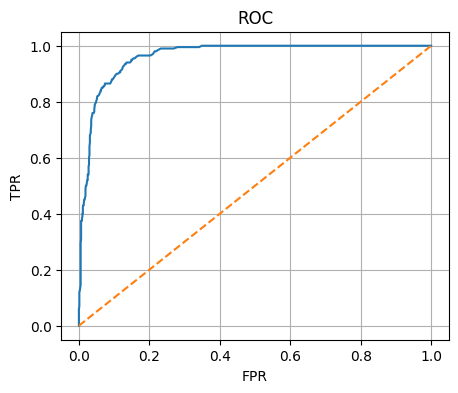

Saved trained pipeline to: /content/output/risk_model.joblib
Saved a sample of predictions to /content/output/predictions_sample.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ======= Paste this full cell into Google Colab (or Jupyter) and run =======
# Install dependencies (Colab usually has these; this ensures widgets are present)
!pip install -q scikit-learn pandas matplotlib ipywidgets joblib

# ---------- Imports ----------
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_curve, precision_recall_curve
import joblib
import matplotlib.pyplot as plt

# For Colab file upload/download and interactive widgets
from google.colab import files
import ipywidgets as widgets
from IPython.display import display, clear_output

# ---------- 1) Dataset creation / upload ----------
def generate_synthetic_patient_data(n_samples=5000, seed=42):
    np.random.seed(seed)
    n = n_samples
    age = np.random.randint(18, 90, size=n)
    sex = np.random.choice(['M', 'F'], size=n, p=[0.48, 0.52])
    bmi = np.round(np.random.normal(27, 6, size=n), 1)
    sbp = np.round(np.random.normal(125 + (age - 50) * 0.2, 14, size=n)).astype(int)
    dbp = np.round(np.random.normal(78 + (age - 50) * 0.05, 10, size=n)).astype(int)
    hr = np.round(np.random.normal(78, 12, size=n)).astype(int)
    temp = np.round(np.random.normal(36.6, 0.4, size=n), 1)
    oxy = np.round(np.clip(np.random.normal(96, 2, size=n), 70, 100), 1)
    respiratory_rate = np.round(np.random.normal(16, 2, size=n)).astype(int)
    hgb = np.round(np.random.normal(13.5 - 0.02*(age-50), 1.2, size=n), 1)
    wbc = np.round(np.abs(np.random.normal(7, 3, size=n)), 1)
    creat = np.round(np.abs(np.random.normal(1.0 + 0.01*(age-50), 0.4, size=n)), 2)
    glucose = np.round(np.abs(np.random.normal(110 + 0.5*(age-50), 40, size=n)), 1)
    sodium = np.round(np.random.normal(139, 3, size=n), 1)
    potassium = np.round(np.random.normal(4.2, 0.4, size=n), 2)

    p_age = 1 / (1 + np.exp(-(age - 50) / 10))
    diabetes = (np.random.rand(n) < (0.05 + 0.25 * p_age)).astype(int)
    hypertension = (np.random.rand(n) < (0.1 + 0.5 * p_age)).astype(int)
    chf = (np.random.rand(n) < (0.02 + 0.06 * p_age)).astype(int)
    ckd = (np.random.rand(n) < (0.01 + 0.05 * p_age)).astype(int)
    copd = (np.random.rand(n) < (0.02 + 0.08 * p_age)).astype(int)
    prior_admissions = np.random.poisson(0.6 + 0.02 * p_age * 10, size=n)
    meds_count = np.random.poisson(2 + 0.05 * p_age * 10, size=n)
    smoking = np.random.choice(['never', 'former', 'current'], size=n, p=[0.6, 0.25, 0.15])
    activity = np.random.choice(['low', 'moderate', 'high'], size=n, p=[0.35, 0.45, 0.2])

    df = pd.DataFrame({
        'age': age, 'sex': sex, 'bmi': bmi, 'sbp': sbp, 'dbp': dbp, 'hr': hr,
        'temp': temp, 'oxy': oxy, 'respiratory_rate': respiratory_rate,
        'hgb': hgb, 'wbc': wbc, 'creatinine': creat, 'glucose': glucose,
        'sodium': sodium, 'potassium': potassium,
        'diabetes': diabetes, 'hypertension': hypertension, 'chf': chf, 'ckd': ckd, 'copd': copd,
        'prior_admissions': prior_admissions, 'meds_count': meds_count,
        'smoking': smoking, 'activity': activity
    })

    # synthetic risk score and label consistent with problem image
    risk_score = (
        0.02*(df['age'] - 50) +
        0.8*df['chf'] + 0.6*df['ckd'] + 0.5*df['diabetes'] + 0.45*df['hypertension'] + 0.4*df['copd'] +
        0.25*(df['prior_admissions'] > 0).astype(int) +
        0.15*(df['meds_count'] > 5).astype(int) +
        0.35*((df['oxy'] < 92).astype(int)) +
        0.25*((df['sbp'] > 160) | (df['sbp'] < 90)).astype(int) +
        0.3*((df['creatinine'] > 1.5).astype(int)) +
        0.25*((df['glucose'] > 180).astype(int)) +
        0.15*((df['wbc'] > 12).astype(int)) +
        0.05*((df['bmi'] > 35).astype(int)) +
        0.1*(df['smoking'] == 'current').astype(int)
    )
    risk_score = (risk_score - risk_score.mean())/risk_score.std() + np.random.normal(0, 0.3, size=n)
    thresh_low = np.percentile(risk_score, 50)  # split for multi-class mapping if needed
    thresh_high = np.percentile(risk_score, 80)
    df['risk_score'] = np.round((risk_score - risk_score.min()) / (risk_score.max() - risk_score.min()), 3)
    # create binary high_risk (original label) and also a 3-tier label for validation convenience
    df['high_risk'] = (risk_score > thresh_high).astype(int)
    df['risk_tier'] = pd.cut(risk_score, bins=[-np.inf, np.percentile(risk_score,50), np.percentile(risk_score,80), np.inf], labels=['Low','Moderate','High'])
    return df

# Allow user to upload their CSV (optional)
print("If you have 'patient_risk_dataset.csv' locally and want to use it, upload it in the file picker that appears. Otherwise cancel/close to auto-generate a synthetic dataset.")
uploaded = files.upload()  # click choose files to upload a CSV named patient_risk_dataset.csv (optional)
if 'patient_risk_dataset.csv' in uploaded:
    df = pd.read_csv('patient_risk_dataset.csv')
    print("Loaded uploaded dataset: patient_risk_dataset.csv")
else:
    df = generate_synthetic_patient_data(n_samples=5000)
    df.to_csv('patient_risk_dataset.csv', index=False)
    print("Generated synthetic dataset and saved to 'patient_risk_dataset.csv'")

# show first rows
print("Preview of dataset:")
display(df.head())

# ---------- 2) Preprocessing & model pipeline ----------
target = 'high_risk'  # binary target (keeps consistent with problem image)
features = [c for c in df.columns if c not in [target, 'risk_score', 'risk_tier']]

# numeric and categorical lists (matches the image's fields)
numeric_cols = [
    'age','bmi','sbp','dbp','hr','temp','oxy','respiratory_rate',
    'hgb','wbc','creatinine','glucose','sodium','potassium','prior_admissions','meds_count'
]
categorical_cols = ['sex','smoking','activity','diabetes','hypertension','chf','ckd','copd']

# sanity: if user's CSV has slightly different columns, attempt to auto-handle (basic)
for col in numeric_cols + categorical_cols:
    if col not in features:
        raise ValueError(f"Expected column '{col}' in dataset (present columns: {features[:10]}...). Please upload a CSV with the required columns or regenerate.")

X = df[features]
y = df[target]

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# transformers
num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', num_pipeline, numeric_cols), ('cat', cat_pipeline, categorical_cols)])

# full pipeline with RandomForest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
full_pipeline = Pipeline([('preprocessor', preprocessor), ('rf', rf)])

# Quick training (set QUICK=False below if you want hyperparam search; QUICK=True runs faster)
QUICK = True

if QUICK:
    full_pipeline.fit(X_train, y_train)
    model = full_pipeline
    print("Trained RandomForest pipeline in QUICK mode.")
else:
    param_dist = {'rf__n_estimators': [100,200,400], 'rf__max_depth': [5,10,20,None], 'rf__min_samples_leaf': [1,2,4]}
    search = RandomizedSearchCV(full_pipeline, param_dist, n_iter=8, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1)
    search.fit(X_train, y_train)
    model = search.best_estimator_
    print("Trained with RandomizedSearchCV. Best params:", search.best_params_)

# ---------- 3) Evaluation ----------
y_proba = model.predict_proba(X_test)[:,1]
y_pred = model.predict(X_test)
metrics = {
    'roc_auc': roc_auc_score(y_test, y_proba),
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred)
}
print("Test metrics:", metrics)
print("\nClassification report:\n", classification_report(y_test, y_pred))

# ROC plot
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5,4)); plt.plot(fpr,tpr); plt.plot([0,1],[0,1],'--'); plt.title('ROC'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.grid(True); plt.show()

# ---------- 4) Save model & sample predictions ----------
os.makedirs('/content/output', exist_ok=True)
model_path = '/content/output/risk_model.joblib'
joblib.dump(model, model_path)
print("Saved trained pipeline to:", model_path)

out = X_test.copy()
out['true_high_risk'] = y_test.values
out['pred_proba'] = np.round(y_proba,3)
out['pred_label'] = y_pred
out.to_csv('/content/output/predictions_sample.csv', index=False)
print("Saved a sample of predictions to /content/output/predictions_sample.csv")
files.download('/content/output/predictions_sample.csv')

# ---------- 5) Helpers: probability -> 3-tier mapping and care plans ----------
# You can tune thresholds to match your desired sensitivity/specificity
LOW_THRESHOLD = 0.33
HIGH_THRESHOLD = 0.66

def proba_to_tier(p, low=LOW_THRESHOLD, high=HIGH_THRESHOLD):
    if p < low:
        return 'Low'
    elif p < high:
        return 'Moderate'
    else:
        return 'High'

def care_plan_for_tier(tier):
    if tier == 'Low':
        return {
            'title': '✅ Low Risk — Preventive Care & Lifestyle',
            'recommendations': [
                'Maintain healthy lifestyle: 150 min moderate exercise/week, balanced diet (DASH/Mediterranean).',
                'Annual BP, fasting glucose, lipid profile.',
                'Smoking cessation counseling if applicable.',
                'Reassess risk annually or if symptoms develop.'
            ],
            'clinical_guideline_notes': [
                'Focus on primary prevention and education.',
                'Consider immunizations and routine screening per age.'
            ],
            'protocol': [
                'Schedule annual primary care visit.',
                'Provide educational materials and community resources.'
            ]
        }
    elif tier == 'Moderate':
        return {
            'title': '⚠️ Moderate Risk — Close Monitoring + Preventive Therapy',
            'recommendations': [
                'Lifestyle interventions with structured weight loss program if BMI ≥25.',
                'Measure BP every 3 months; consider starting antihypertensive if persistent ≥140/90.',
                'Repeat labs (lipid panel, HbA1c) every 6-12 months; consider statin if indicated.',
                'Smoking cessation program & referral to dietitian.'
            ],
            'clinical_guideline_notes': [
                'Assess 10-year cardiovascular risk; consider pharmacologic prevention per ACC/AHA.',
                'If diabetic, tighten glycemic control per ADA guidance.'
            ],
            'protocol': [
                'Primary care follow-up q3 months.',
                'Order A1c/lipid panels; adjust meds as needed.',
                'Refer to allied health (dietitian, physiotherapist) for structured interventions.'
            ]
        }
    elif tier == 'High':
        return {
            'title': '🚨 High Risk — Immediate Evaluation & Active Management',
            'recommendations': [
                'Urgent clinical evaluation by PCP; consider specialist referrals (Cardiology, Endocrinology, Nephrology).',
                'Start/optimize guideline-directed therapies: antihypertensives, statins, diabetes medications as appropriate.',
                'Intensive monitoring: BP monthly, HbA1c q3 months, kidney function q3 months.',
                'Consider hospital evaluation if hemodynamically unstable or signs of organ dysfunction.'
            ],
            'clinical_guideline_notes': [
                'Follow condition-specific guidelines (AHA/ACC for cardiac disease, ADA for diabetes, KDIGO for CKD).',
                'Coordinate a multidisciplinary care plan and create a follow-up schedule.'
            ],
            'protocol': [
                'Create individualized care plan; schedule weekly (initial) → monthly reviews.',
                'Start case management / nurse follow-up and arrange rapid access to clinic.'
            ]
        }

# ---------- 6) Interactive form for single-patient user input ----------
# Widget definitions (one widget per input field used in model)
w_age = widgets.IntSlider(value=50, min=18, max=90, step=1, description='Age:')
w_sex = widgets.Dropdown(options=['M','F'], value='M', description='Sex:')
w_bmi = widgets.FloatSlider(value=27.0, min=12.0, max=50.0, step=0.1, description='BMI:')
w_sbp = widgets.IntSlider(value=125, min=60, max=220, step=1, description='SBP:')
w_dbp = widgets.IntSlider(value=80, min=40, max=140, step=1, description='DBP:')
w_hr = widgets.IntSlider(value=78, min=30, max=150, step=1, description='HR:')
w_temp = widgets.FloatSlider(value=36.6, min=34.0, max=40.0, step=0.1, description='Temp:')
w_oxy = widgets.FloatSlider(value=96.0, min=70.0, max=100.0, step=0.1, description='SpO2:')
w_rr = widgets.IntSlider(value=16, min=8, max=40, step=1, description='RR:')
w_hgb = widgets.FloatSlider(value=13.5, min=6.0, max=18.0, step=0.1, description='Hgb:')
w_wbc = widgets.FloatSlider(value=7.0, min=1.0, max=30.0, step=0.1, description='WBC:')
w_creat = widgets.FloatSlider(value=1.0, min=0.2, max=6.0, step=0.01, description='Creat:')
w_glucose = widgets.IntSlider(value=110, min=50, max=400, step=1, description='Glucose:')
w_sodium = widgets.FloatSlider(value=139.0, min=120.0, max=160.0, step=0.1, description='Na:')
w_potassium = widgets.FloatSlider(value=4.2, min=2.5, max=6.0, step=0.01, description='K:')
w_diabetes = widgets.Dropdown(options=[0,1], value=0, description='Diabetes:')
w_hypertension = widgets.Dropdown(options=[0,1], value=0, description='HTN:')
w_chf = widgets.Dropdown(options=[0,1], value=0, description='CHF:')
w_ckd = widgets.Dropdown(options=[0,1], value=0, description='CKD:')
w_copd = widgets.Dropdown(options=[0,1], value=0, description='COPD:')
w_prior_adm = widgets.IntSlider(value=0, min=0, max=20, step=1, description='PriorAdmissions:')
w_meds_count = widgets.IntSlider(value=2, min=0, max=20, step=1, description='MedsCount:')
w_smoking = widgets.Dropdown(options=['never','former','current'], value='never', description='Smoking:')
w_activity = widgets.Dropdown(options=['low','moderate','high'], value='moderate', description='Activity:')

predict_button = widgets.Button(description='Predict Risk & Show Care Plan', button_style='success')
form_output = widgets.Output()

def on_predict_clicked(b):
    with form_output:
        clear_output()
        # Build single-row DataFrame with same columns as training features
        patient = {
            'age': int(w_age.value),
            'sex': w_sex.value,
            'bmi': float(w_bmi.value),
            'sbp': int(w_sbp.value),
            'dbp': int(w_dbp.value),
            'hr': int(w_hr.value),
            'temp': float(w_temp.value),
            'oxy': float(w_oxy.value),
            'respiratory_rate': int(w_rr.value),
            'hgb': float(w_hgb.value),
            'wbc': float(w_wbc.value),
            'creatinine': float(w_creat.value),
            'glucose': int(w_glucose.value),
            'sodium': float(w_sodium.value),
            'potassium': float(w_potassium.value),
            'diabetes': int(w_diabetes.value),
            'hypertension': int(w_hypertension.value),
            'chf': int(w_chf.value),
            'ckd': int(w_ckd.value),
            'copd': int(w_copd.value),
            'prior_admissions': int(w_prior_adm.value),
            'meds_count': int(w_meds_count.value),
            'smoking': w_smoking.value,
            'activity': w_activity.value
        }
        X_patient = pd.DataFrame([patient])[features]  # ensure column order

        # Predict proba and tier
        proba = model.predict_proba(X_patient)[:,1][0]
        tier = proba_to_tier(proba)
        plan = care_plan_for_tier(tier)

        # Print results
        print(f"Predicted probability of adverse outcome (high-risk): {proba:.3f}")
        print(f"Risk tier: {tier}")
        print("\n" + plan['title'])
        print("\nRecommendations:")
        for rec in plan['recommendations']:
            print(" •", rec)
        print("\nClinical guideline notes:")
        for note in plan['clinical_guideline_notes']:
            print(" •", note)
        print("\nCare protocol (practical steps):")
        for step in plan['protocol']:
            print(" •", step)

predict_button.on_click(on_predict_clicked)

# Display the interactive form
display(widgets.VBox([
    widgets.HBox([w_age, w_sex, w_bmi]),
    widgets.HBox([w_sbp, w_dbp, w_hr]),
    widgets.HBox([w_temp, w_oxy, w_rr]),
    widgets.HBox([w_hgb, w_wbc, w_creat]),
    widgets.HBox([w_glucose, w_sodium, w_potassium]),
    widgets.HBox([w_diabetes, w_hypertension, w_chf, w_ckd, w_copd]),
    widgets.HBox([w_prior_adm, w_meds_count, w_smoking, w_activity]),
    predict_button,
    form_output
]))
# ========================================================================